# LAPORAN TUGAS BESAR STATISTIKA & PROBABILITAS (STATPROB)
## Analisis Data Eksploratif: Faktor-Faktor Penentu Kepuasan Penumpang Maskapai Penerbangan *(Airline Passenger Satisfaction)*

**Nama Kelompok:** Day in My Anaconda  
**Program Studi / Mata Kuliah:** Statistika & Probabilitas  
**Dataset Utama:** `data/train.csv` (103.904 baris observasi, 24 fitur analitis)  

---

### Pembagian Tugas Anggota Kelompok
Untuk memastikan alur kerja yang terstruktur dan mendalam, kelompok kami membagi tanggung jawab analisis ke dalam tiga bagian utama:
1. **Dyah Indana Zulfa** — **Modul 1: Pemahaman Data & Audit Kualitas Data**
   * *Tugas:* Pemuatan dataset mentah, penyusunan kamus data dan taksonomi fitur, pengujian mekanisme missing value (MCAR vs. MAR), perbandingan empiris metode imputasi, evaluasi anomali rating 0, serta analisis nilai ekstrem pada data keterlambatan.
2. **Andika Pratama** — **Modul 2: Analisis Univariat & Profiling Data**
   * *Tugas:* Pemeriksaan keseimbangan variabel target, analisis sebaran demografi dan karakteristik penerbangan, pemetaan distribusi variabel numerik, serta evaluasi komparatif skor rata-rata pada 14 fasilitas layanan maskapai.
3. **Sheva Ramadhan** — **Modul 3: Analisis Bivariat, Uji Confounding, & Pemodelan Prediktif**
   * *Tugas:* Pengujian kekuatan asosiasi kategorikal (Cramér's V), deteksi kurva non-linear "U" pada rating layanan (Grafik Kunci 1), pembongkaran korelasi semu jarak penerbangan (Grafik Kunci 2 / Simpson's Paradox), perancangan pipeline preprocessing data-driven, serta validasi hipotesis menggunakan model machine learning baseline.

---

### Ringkasan Temuan Utama Analisis Data
Berdasarkan investigasi data yang telah dilakukan terhadap 103.904 data penumpang, kelompok kami merangkum beberapa temuan kunci:
1. **Hubungan Non-Linear yang Signifikan:** Hubungan antara tingkat kepuasan dengan sebagian besar fasilitas layanan tidak bersifat garis lurus. Model pohon non-linear (*HistGradientBoosting*) mampu mencapai akurasi **96,4%** (ROC-AUC **0,995**), unggul jauh dibandingkan model linear (*Logistic Regression*) yang mencatat akurasi 90,3% (ROC-AUC 0,966).
2. **Rating 0 Bukan Data Hilang (*Missing Value*):** Penumpang yang memberikan nilai rating 0 pada layanan *Inflight wifi service* memiliki tingkat kepuasan mencapai **99,7%**. Nilai 0 mengindikasikan bahwa penumpang tidak menggunakan fasilitas tersebut, bukan memberikan penilaian buruk. Mengimputasi nilai 0 menjadi median atau rata-rata adalah langkah yang keliru.
3. **Pola Ekspektasi Layanan Berbentuk Kurva "U":** Pada layanan digital (seperti wifi dan online boarding), rating 1, 2, dan 3 menghasilkan persentase kepuasan yang hampir sama rendahnya (~12% hingga 25%), lalu melonjak drastis pada rating 4 (~60%) dan rating 5 (87% hingga 99%).
4. **Korelasi Jarak Penerbangan Bersifat Semu (*Confounding Effect*):** Jarak tempuh yang lebih panjang secara agregat tampak berkorelasi positif dengan kepuasan (+0,30). Namun, di dalam kelas ekonomi (*Eco* dan *Eco Plus*), jarak yang lebih jauh justru menurunkan kepuasan penumpang. Jarak penerbangan semata-mata merupakan proksi dari kelas kabin *Business Class*.
5. **Faktor Penentu Utama:** Kelas kabin (*Class*, Cramér's V = 0,505), tujuan perjalanan (*Type of Travel*, 0,449), dan loyalitas pelanggan (*Customer Type*, 0,188) merupakan faktor yang paling mempengaruhi kepuasan. Sebaliknya, **faktor jenis kelamin (*Gender*) sama sekali tidak berpengaruh** (Cramér's V = 0,012).
6. **Titik Jenuh Dampak Keterlambatan (*Delay*):** Dampak penurunan kepuasan terbesar terjadi pada rentang keterlambatan 1 hingga 15 menit pertama. Keterlambatan lebih dari 15 menit hingga di atas 3 jam menghasilkan tingkat kepuasan yang stabil pada kisaran ~35%.
7. **Karakteristik Data Hilang yang Tidak Acak (*Missing at Random*):** Data hilang pada `Arrival Delay in Minutes` (310 baris) terbukti berkaitan dengan keterlambatan keberangkatan. Mengisi nilai hilang menggunakan data `Departure Delay in Minutes` menghasilkan galat absolut rata-rata (MAE) sebesar **4,97 menit**, jauh lebih akurat dibandingkan menggunakan nilai median (MAE **15,18 menit**).

### Inisialisasi Pustaka & Konfigurasi Visualisasi
Kelompok kami menggunakan pustaka standar analisis data Python (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, dan `scikit-learn`). Konfigurasi grafik disetel dengan resolusi tinggi (110 DPI) dan palet warna yang konsisten agar mudah dibaca.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan data pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Pengaturan estetika grafik matplotlib dan seaborn
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# Palet warna konsisten untuk kelompok kami
WARNA_UTAMA = '#2b5876'
WARNA_KEDUA = '#e74c3c'
WARNA_KETIGA = '#2ecc71'
PALET_KELOMPOK = [WARNA_UTAMA, WARNA_KEDUA, WARNA_KETIGA, '#f39c12', '#9b59b6', '#34495e']
sns.set_palette(PALET_KELOMPOK)

print("Status: Seluruh pustaka berhasil dimuat.")

Status: Seluruh pustaka berhasil dimuat.


---
## BAB I: PEMAHAMAN DATA & AUDIT KUALITAS DATA
**Penanggung Jawab Bagian: Dyah Indana Zulfa**

Pada bagian ini, Dyah melakukan audit terhadap struktur data awal dari berkas `data/train.csv`. Langkah-langkah yang dilakukan mencakup pemuatan data, penghapusan kolom yang tidak relevan, verifikasi integritas baris/ID, penyusunan kamus data, analisis sifat *missing value*, investigasi anomali rating 0, serta pengujian nilai ekstrem pada variabel keterlambatan.

In [2]:
# 1. Pemuatan Data Mentah train.csv
# Menghapus kolom 'Unnamed: 0' yang merupakan index sisa saat ekspor berkas csv
train = pd.read_csv('data/train.csv').drop(columns=['Unnamed: 0'], errors='ignore')

print("=== Ringkasan Dimensi & Integritas Data ===")
print(f"Jumlah baris observasi : {train.shape[0]:,} baris")
print(f"Jumlah kolom fitur     : {train.shape[1]} kolom")
print(f"Jumlah baris duplikat  : {train.drop(columns=['id']).duplicated().sum()} baris")
print(f"Jumlah ID duplikat     : {train['id'].duplicated().sum()} ID")

# 2. Pengelompokan Kolom Berdasarkan Sifat Pengukuran
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Membuat representasi target numerik biner (1: satisfied, 0: neutral or dissatisfied)
train["sat"] = (train["satisfaction"] == "satisfied").astype(int)

# 3. Kamus Data & Taksonomi Fitur
kamus_data = pd.DataFrame({
    'Nama Kolom': train.columns,
    'Tipe Data': train.dtypes.values,
    'Kategori Analitis': [
        'Identifier (ID Unik)' if c == 'id' else
        'Target Analisis (Biner)' if c in ['satisfaction', 'sat'] else
        'Kategorikal Nominal Biner' if c in ['Gender', 'Customer Type', 'Type of Travel'] else
        'Kategorikal Ordinal' if c == 'Class' else
        'Skala Rating Layanan (0-5)' if c in rating_cols else
        'Numerik Kontinu/Diskrit' for c in train.columns
    ],
    'Jumlah Nilai Unik': [train[c].nunique() for c in train.columns],
    'Contoh Nilai': [str(train[c].dropna().unique()[:3].tolist()) for c in train.columns]
})
display(kamus_data)

=== Ringkasan Dimensi & Integritas Data ===
Jumlah baris observasi : 103,904 baris
Jumlah kolom fitur     : 24 kolom
Jumlah baris duplikat  : 0 baris
Jumlah ID duplikat     : 0 ID


,Nama Kolom,Tipe Data,Kategori Analitis,Jumlah Nilai Unik,Contoh Nilai
0,id,int64,Identifier (ID Unik),103904,"[70172, 5047, 110028]"
1,Gender,str,Kategorikal Nominal Biner,2,"['Male', 'Female']"
2,Customer Type,str,Kategorikal Nominal Biner,2,"['Loyal Customer', 'disloyal Customer']"
3,Age,int64,Numerik Kontinu/Diskrit,75,"[13, 25, 26]"
4,Type of Travel,str,Kategorikal Nominal Biner,2,"['Personal Travel', 'Business travel']"
5,Class,str,Kategorikal Ordinal,3,"['Eco Plus', 'Business', 'Eco']"
6,Flight Distance,int64,Numerik Kontinu/Diskrit,3802,"[460, 235, 1142]"
7,Inflight wifi service,int64,Skala Rating Layanan (0-5),6,"[3, 2, 4]"
8,Departure/Arrival time convenient,int64,Skala Rating Layanan (0-5),6,"[4, 2, 5]"
9,Ease of Online booking,int64,Skala Rating Layanan (0-5),6,"[3, 2, 5]"


### 1.2 Analisis Nilai Hilang (*Missing Value*): Uji Sifat MCAR vs. MAR
Pemeriksaan awal menunjukkan bahwa dari 24 kolom yang ada, hanya kolom `Arrival Delay in Minutes` yang memiliki nilai hilang, yaitu sebanyak 310 baris (0,30% dari total data).

Untuk menentukan metode penanganan yang tepat, Dyah menguji apakah data hilang ini terjadi secara acak murni (*Missing Completely at Random* / MCAR) ataukah berkaitan dengan variabel lain (*Missing at Random* / MAR). Kami membandingkan nilai `Departure Delay in Minutes` antara data yang memiliki nilai `Arrival Delay` lengkap dengan data yang nilai `Arrival Delay`-nya hilang.

Variabel dengan nilai hilang:
Arrival Delay in Minutes    310
dtype: int64

Statistik Departure Delay saat data Arrival Delay HILANG (n = 310):


count    310.00
mean      37.43
50%        8.00
std       62.24
max      455.00
Name: Departure Delay in Minutes, dtype: float64

Statistik Departure Delay saat data Arrival Delay LENGKAP (n = 103.594):


count    103594.00
mean         14.75
50%           0.00
std          38.12
max        1592.00
Name: Departure Delay in Minutes, dtype: float64

Mean Absolute Error (MAE) jika diisi Median           : 15.18 menit
Mean Absolute Error (MAE) jika diisi Departure Delay  : 4.97 menit


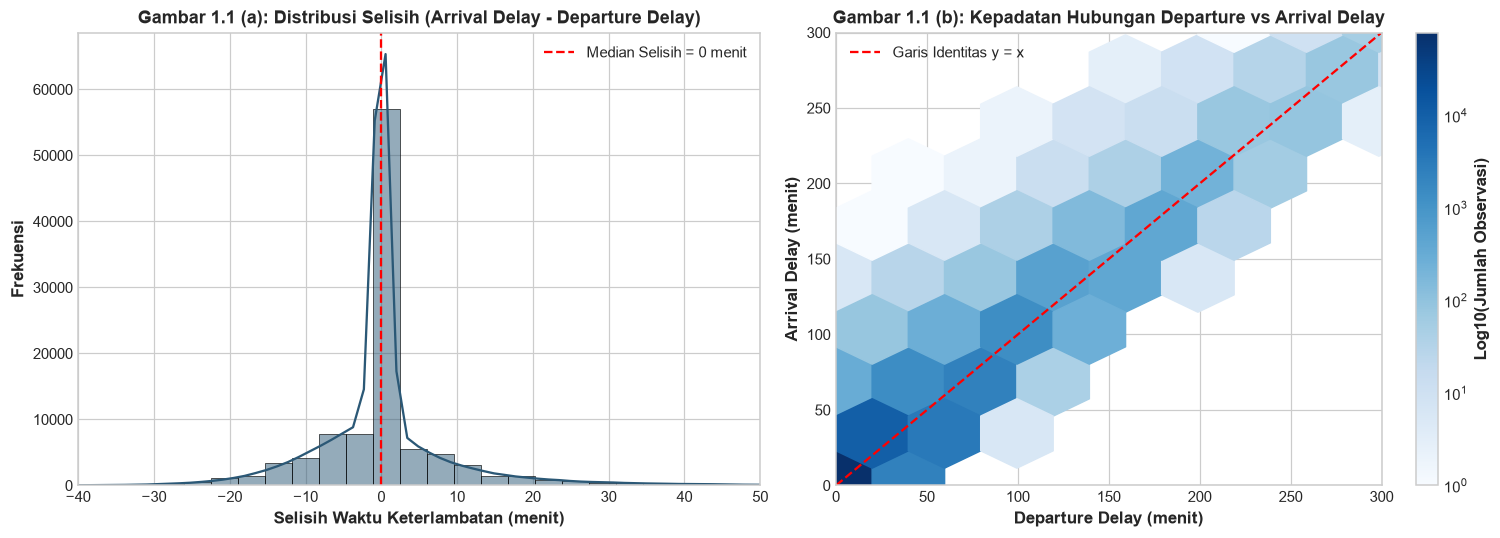

In [3]:
# Pemeriksaan data hilang pada setiap kolom
missing_series = train.isna().sum()[lambda s: s > 0]
print("Variabel dengan nilai hilang:")
print(missing_series)

# Uji perbandingan: Nilai Departure Delay saat Arrival Delay hilang vs lengkap
is_missing = train["Arrival Delay in Minutes"].isna()
print("\nStatistik Departure Delay saat data Arrival Delay HILANG (n = 310):")
display(train.loc[is_missing, "Departure Delay in Minutes"].describe()[['count', 'mean', '50%', 'std', 'max']].round(2))

print("Statistik Departure Delay saat data Arrival Delay LENGKAP (n = 103.594):")
display(train.loc[~is_missing, "Departure Delay in Minutes"].describe()[['count', 'mean', '50%', 'std', 'max']].round(2))

# Komparasi Empiris: Imputasi Median vs Imputasi Nilai Departure Delay
data_lengkap = train.dropna(subset=["Arrival Delay in Minutes"])
nilai_aktual = data_lengkap["Arrival Delay in Minutes"]
nilai_departure = data_lengkap["Departure Delay in Minutes"]

galat_median = np.abs(nilai_aktual - nilai_aktual.median()).mean()
galat_departure = np.abs(nilai_aktual - nilai_departure).mean()

print(f"Mean Absolute Error (MAE) jika diisi Median           : {galat_median:.2f} menit")
print(f"Mean Absolute Error (MAE) jika diisi Departure Delay  : {galat_departure:.2f} menit")

# Gambar 1.1: Visualisasi Distribusi Selisih Delay dan Korelasi Hexbin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi selisih antara Arrival Delay dan Departure Delay
selisih_delay = nilai_aktual - nilai_departure
sns.histplot(selisih_delay, bins=80, kde=True, color=WARNA_UTAMA, ax=axes[0])
axes[0].set_xlim(-40, 50)
axes[0].set_title("Gambar 1.1 (a): Distribusi Selisih (Arrival Delay - Departure Delay)")
axes[0].set_xlabel("Selisih Waktu Keterlambatan (menit)")
axes[0].set_ylabel("Frekuensi")
axes[0].axvline(0, color='red', linestyle='--', label='Median Selisih = 0 menit')
axes[0].legend()

# Plot 2: Hexbin plot korelasi keberangkatan dan kedatangan
hb = axes[1].hexbin(nilai_departure, nilai_aktual, gridsize=40, cmap='Blues', mincnt=1, bins='log')
axes[1].plot([0, 300], [0, 300], 'r--', label='Garis Identitas y = x')
axes[1].set_xlim(0, 300)
axes[1].set_ylim(0, 300)
axes[1].set_title("Gambar 1.1 (b): Kepadatan Hubungan Departure vs Arrival Delay")
axes[1].set_xlabel("Departure Delay (menit)")
axes[1].set_ylabel("Arrival Delay (menit)")
axes[1].legend()
cb = fig.colorbar(hb, ax=axes[1])
cb.set_label('Log10(Jumlah Observasi)')

plt.tight_layout()
plt.show()

### 1.3 Investigasi Nilai Rating 0: Mengapa Tidak Boleh Dihapus atau Diimputasi?
Pada kuesioner berskala 1 sampai 5, nilai 0 sering disalahartikan sebagai data yang tidak valid. Namun, setelah Dyah memeriksa korelasi nilai 0 terhadap target kepuasan, ditemukan bahwa **penumpang yang memberi nilai 0 pada fasilitas wifi memiliki kepuasan 99,7%**.

Hal ini mengindikasikan bahwa nilai 0 menandakan penumpang yang tidak menggunakan fasilitas tersebut (misalnya tidak membeli akses wifi di pesawat). Karena membawa informasi perilaku yang sangat spesifik, nilai 0 tidak boleh diubah menjadi nilai rata-rata atau NaN.

,Layanan,Frekuensi Nilai 0,Persentase terhadap Total,Tingkat Kepuasan saat Rating 0 (%)
1,Departure/Arrival time convenient,5300,5.10,47.5
2,Ease of Online booking,4487,4.32,66.4
0,Inflight wifi service,3103,2.99,99.7
5,Online boarding,2428,2.34,55.6
9,Leg room service,472,0.45,35.2
4,Food and drink,107,0.10,46.7
7,Inflight entertainment,14,0.01,0.0
12,Cleanliness,12,0.01,0.0
11,Inflight service,3,0.00,0.0
8,On-board service,3,0.00,0.0


Tingkat kepuasan penumpang dengan >= 3 rating bernilai 0 : 88.2% (n = 2,614)
Tingkat kepuasan penumpang tanpa ada rating bernilai 0   : 42.6% (n = 95,704)


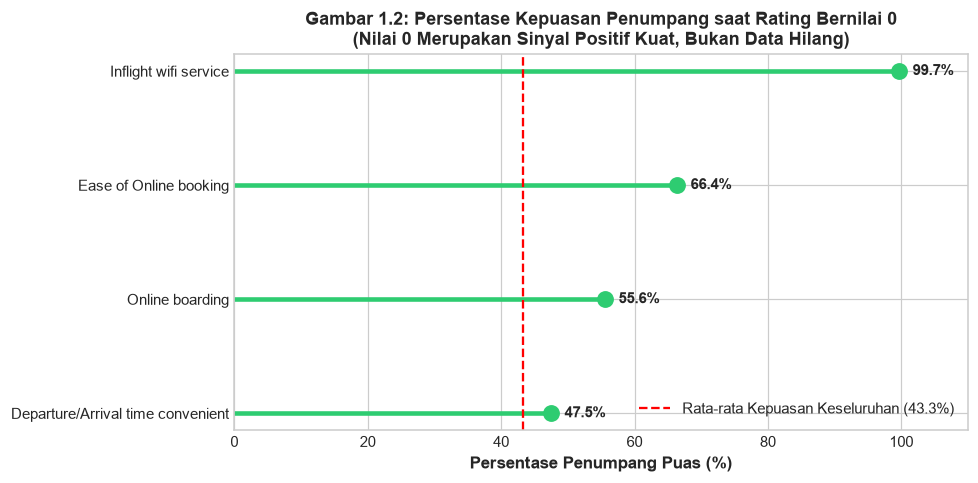

In [4]:
# Menghitung frekuensi nilai 0 dan tingkat kepuasan pada tiap layanan
rekap_nol = []
for c in rating_cols:
    jumlah_0 = (train[c] == 0).sum()
    if jumlah_0 > 0:
        kepuasan_0 = train[train[c] == 0]["sat"].mean() * 100
        rekap_nol.append({
            'Layanan': c,
            'Frekuensi Nilai 0': jumlah_0,
            'Persentase terhadap Total': round((jumlah_0 / len(train)) * 100, 2),
            'Tingkat Kepuasan saat Rating 0 (%)': round(kepuasan_0, 1)
        })

df_rekap_nol = pd.DataFrame(rekap_nol).sort_values(by='Frekuensi Nilai 0', ascending=False)
display(df_rekap_nol)

# Pemeriksaan penumpang dengan banyak nilai rating 0
train["banyak_nol"] = train[rating_cols].eq(0).sum(axis=1)
puas_multi_nol = train[train["banyak_nol"] >= 3]["sat"].mean() * 100
puas_tanpa_nol = train[train["banyak_nol"] == 0]["sat"].mean() * 100
print(f"Tingkat kepuasan penumpang dengan >= 3 rating bernilai 0 : {puas_multi_nol:.1f}% (n = {train['banyak_nol'].ge(3).sum():,})")
print(f"Tingkat kepuasan penumpang tanpa ada rating bernilai 0   : {puas_tanpa_nol:.1f}% (n = {train['banyak_nol'].eq(0).sum():,})")

# Gambar 1.2: Lollipop Chart Kepuasan saat Rating = 0
top_nol = df_rekap_nol.head(4).sort_values(by='Tingkat Kepuasan saat Rating 0 (%)')
plt.figure(figsize=(9, 4.5))
plt.hlines(y=top_nol['Layanan'], xmin=0, xmax=top_nol['Tingkat Kepuasan saat Rating 0 (%)'], color=WARNA_KETIGA, lw=3)
plt.plot(top_nol['Tingkat Kepuasan saat Rating 0 (%)'], top_nol['Layanan'], "o", markersize=10, color=WARNA_KETIGA)
plt.axvline(train['sat'].mean()*100, color='red', linestyle='--', label=f"Rata-rata Kepuasan Keseluruhan ({train['sat'].mean()*100:.1f}%)")
plt.title("Gambar 1.2: Persentase Kepuasan Penumpang saat Rating Bernilai 0\n(Nilai 0 Merupakan Sinyal Positif Kuat, Bukan Data Hilang)")
plt.xlabel("Persentase Penumpang Puas (%)")
plt.xlim(0, 110)
for _, r in top_nol.iterrows():
    plt.text(r['Tingkat Kepuasan saat Rating 0 (%)'] + 2, r['Layanan'], f"{r['Tingkat Kepuasan saat Rating 0 (%)']:.1f}%", va='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 1.4 Evaluasi Nilai Ekstrem & Distorsi Batas IQR pada Variabel Keterlambatan
Dyah mengevaluasi sebaran variabel numerik (`Age`, `Flight Distance`, `Departure Delay`, `Arrival Delay`). Data keterlambatan penerbangan memiliki karakteristik *zero-inflated* (lebih dari 56% bernilai 0). 

Rumus baku Tukey ($Q_3 + 1,5 \times \text{IQR}$) keliru menandai 13% hingga 14% observasi keterlambatan sebagai pencilan (*outlier*). Padahal keterlambatan hingga beberapa jam adalah kejadian operasional yang nyata, bukan kesalahan entri data.

,min,25%,50%,75%,max,Kemencengan (Skewness),Keruncingan (Kurtosis)
Age,7.0,27.0,40.0,51.0,85.0,-0.00,-0.72
Flight Distance,31.0,414.0,843.0,1743.0,4983.0,1.11,0.27
Departure Delay in Minutes,0.0,0.0,0.0,12.0,1592.0,6.73,100.27
Arrival Delay in Minutes,0.0,0.0,0.0,13.0,1584.0,6.60,94.54


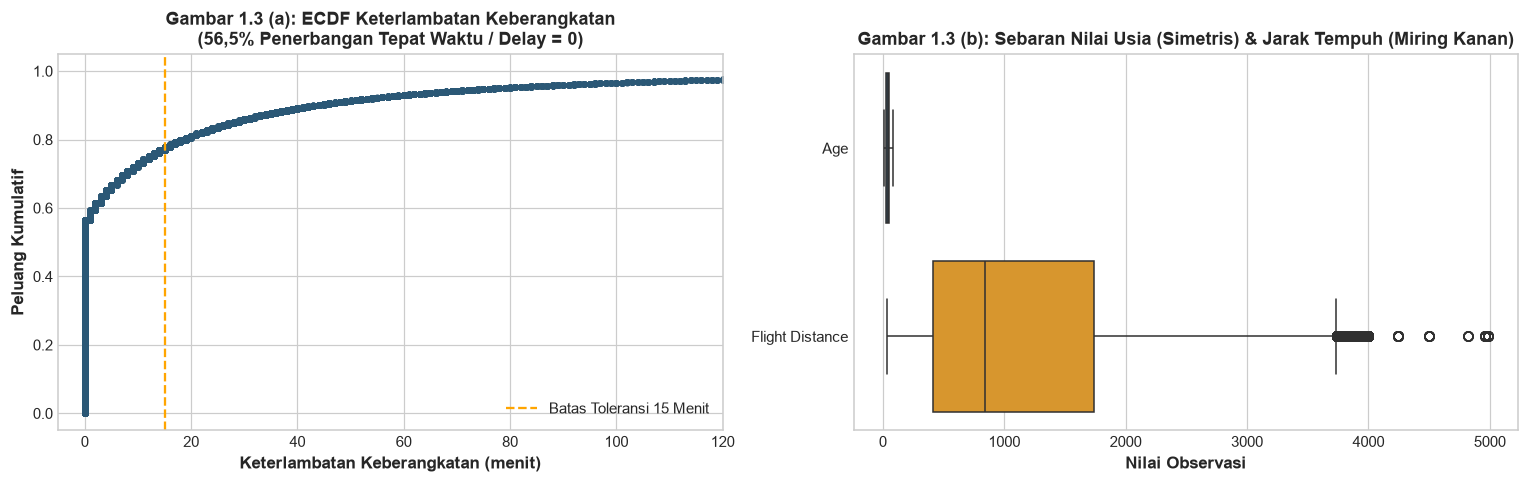

In [5]:
# Statistik Deskriptif Variabel Numerik
statistik_num = train[num_cols].describe().T
statistik_num['Kemencengan (Skewness)'] = train[num_cols].skew()
statistik_num['Keruncingan (Kurtosis)'] = train[num_cols].kurtosis()
display(statistik_num[['min', '25%', '50%', '75%', 'max', 'Kemencengan (Skewness)', 'Keruncingan (Kurtosis)']].round(2))

# Gambar 1.3: ECDF Keterlambatan & Boxplot Variabel Numerik
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Kurva Probabilitas Kumulatif Empiris (ECDF) Departure Delay
delay_terurut = np.sort(train['Departure Delay in Minutes'])
ecdf_y = np.arange(1, len(delay_terurut) + 1) / len(delay_terurut)
axes[0].plot(delay_terurut, ecdf_y, marker='.', linestyle='none', color=WARNA_UTAMA)
axes[0].set_xlim(-5, 120)
axes[0].set_title("Gambar 1.3 (a): ECDF Keterlambatan Keberangkatan\n(56,5% Penerbangan Tepat Waktu / Delay = 0)")
axes[0].set_xlabel("Keterlambatan Keberangkatan (menit)")
axes[0].set_ylabel("Peluang Kumulatif")
axes[0].axvline(15, color='orange', linestyle='--', label='Batas Toleransi 15 Menit')
axes[0].legend()

# Plot 2: Boxplot Horizontal Usia dan Jarak Penerbangan
sns.boxplot(data=train[['Age', 'Flight Distance']], orient='h', palette=[WARNA_UTAMA, '#f39c12'], ax=axes[1])
axes[1].set_title("Gambar 1.3 (b): Sebaran Nilai Usia (Simetris) & Jarak Tempuh (Miring Kanan)")
axes[1].set_xlabel("Nilai Observasi")

plt.tight_layout()
plt.show()

---
## BAB II: ANALISIS UNIVARIAT & PROFIL KARAKTERISTIK PENUMPANG
**Penanggung Jawab Bagian: Andika Pratama**

Pada bagian ini, Andika menganalisis sebaran variabel secara individual: proporsi variabel target kepuasan, karakteristik demografi penumpang (gender, usia, loyalitas), tipe perjalanan, kelas kabin, serta pemetaan skor rata-rata pada 14 aspek layanan maskapai.

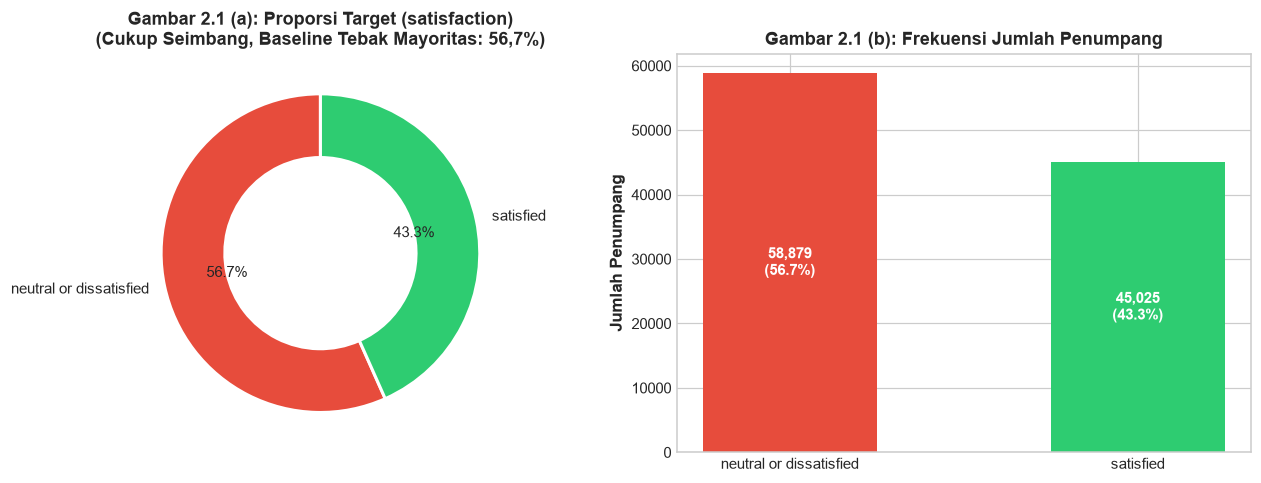

In [6]:
# 1. Analisis Keseimbangan Target Kepuasan
rekap_target = train["satisfaction"].value_counts()
proporsi_target = train["satisfaction"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Donut Chart Target
axes[0].pie(rekap_target, labels=rekap_target.index, autopct='%1.1f%%', startangle=90,
            colors=[WARNA_KEDUA, WARNA_KETIGA], wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[0].set_title("Gambar 2.1 (a): Proporsi Target (satisfaction)\n(Cukup Seimbang, Baseline Tebak Mayoritas: 56,7%)")

# Diagram Batang Frekuensi
batang_target = axes[1].bar(rekap_target.index, rekap_target.values, color=[WARNA_KEDUA, WARNA_KETIGA], width=0.5)
axes[1].set_title("Gambar 2.1 (b): Frekuensi Jumlah Penumpang")
axes[1].set_ylabel("Jumlah Penumpang")
for b in batang_target:
    tinggi = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, tinggi/2, f"{tinggi:,}\n({tinggi/len(train)*100:.1f}%)",
                 ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Distribusi Demografi & Karakteristik Perjalanan Penumpang
Andika memvisualisasikan komposisi profil penumpang berdasarkan jenis kelamin, tipe loyalitas pelanggan, tujuan perjalanan, dan kelas penerbangan.

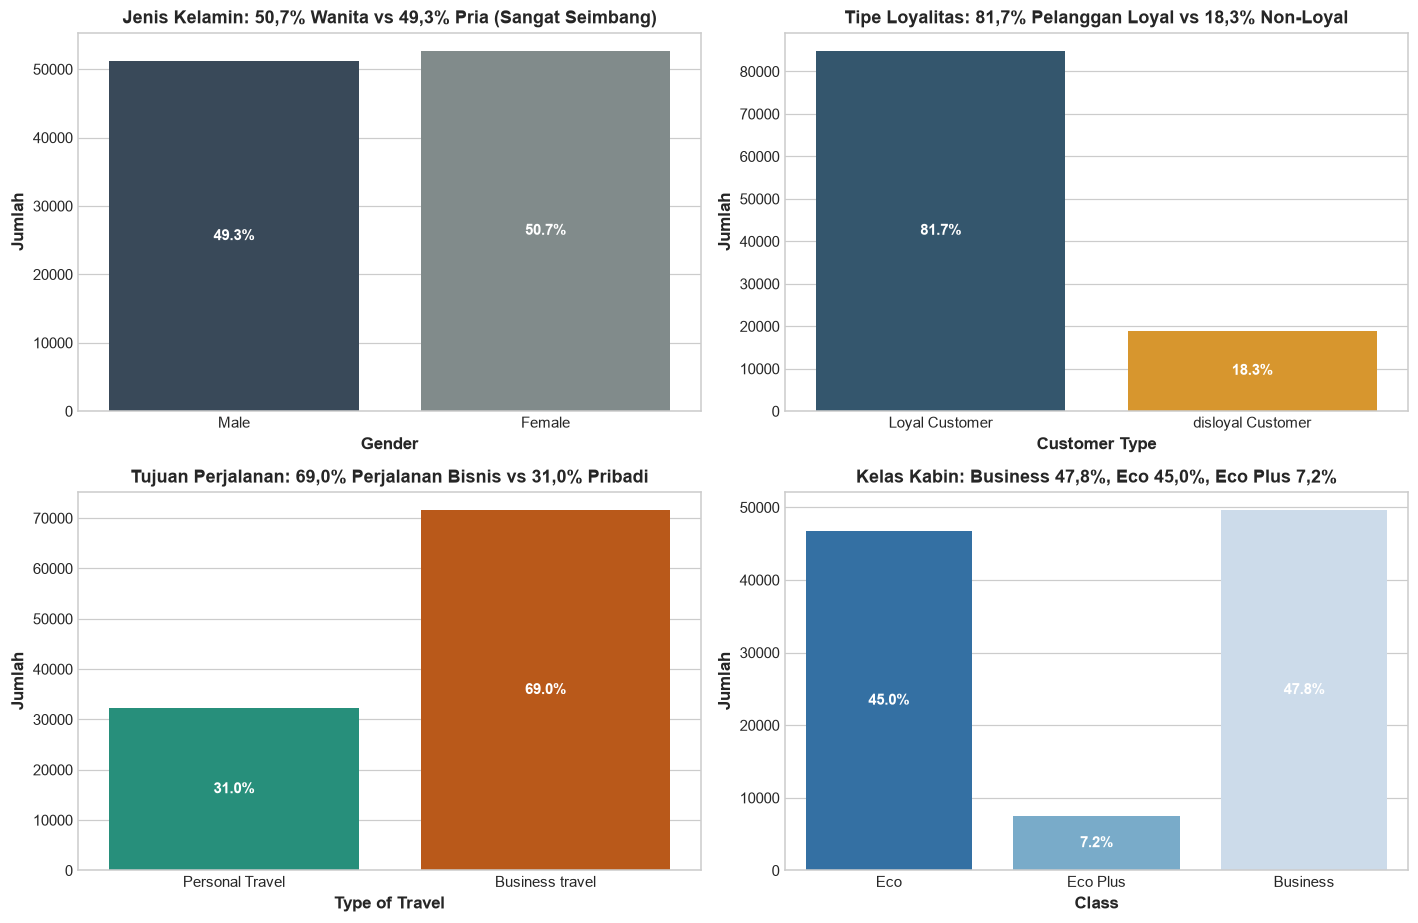

In [7]:
# Gambar 2.2: Distribusi 4 Variabel Kategorikal
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

# 1. Jenis Kelamin (Gender)
sns.countplot(data=train, x="Gender", palette=['#34495e', '#7f8c8d'], ax=axes[0, 0])
axes[0, 0].set_title("Jenis Kelamin: 50,7% Wanita vs 49,3% Pria (Sangat Seimbang)")
axes[0, 0].set_ylabel("Jumlah")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

# 2. Loyalitas Pelanggan (Customer Type)
sns.countplot(data=train, x="Customer Type", palette=[WARNA_UTAMA, '#f39c12'], ax=axes[0, 1])
axes[0, 1].set_title("Tipe Loyalitas: 81,7% Pelanggan Loyal vs 18,3% Non-Loyal")
axes[0, 1].set_ylabel("Jumlah")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

# 3. Tujuan Perjalanan (Type of Travel)
sns.countplot(data=train, x="Type of Travel", palette=['#16a085', '#d35400'], ax=axes[1, 0])
axes[1, 0].set_title("Tujuan Perjalanan: 69,0% Perjalanan Bisnis vs 31,0% Pribadi")
axes[1, 0].set_ylabel("Jumlah")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

# 4. Kelas Penerbangan (Class)
sns.countplot(data=train, x="Class", order=['Eco', 'Eco Plus', 'Business'], palette='Blues_r', ax=axes[1, 1])
axes[1, 1].set_title("Kelas Kabin: Business 47,8%, Eco 45,0%, Eco Plus 7,2%")
axes[1, 1].set_ylabel("Jumlah")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height()/len(train)*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2),
                         ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.3 Evaluasi Komparatif Skor Rata-rata 14 Aspek Layanan Maskapai
Andika menghitung skor rata-rata pada skala 1 sampai 5 untuk seluruh fasilitas layanan (di luar nilai rating 0). Fasilitas ini kemudian dikelompokkan menjadi 3 pilar operasional:
1. **Layanan Digital & Bandara** *(Pre-Flight / Digital Touchpoints)*
2. **Kenyamanan & Fasilitas Kabin** *(In-Flight Comfort)*
3. **Pelayanan Awak Pesawat & Bagasi** *(Physical Service)*

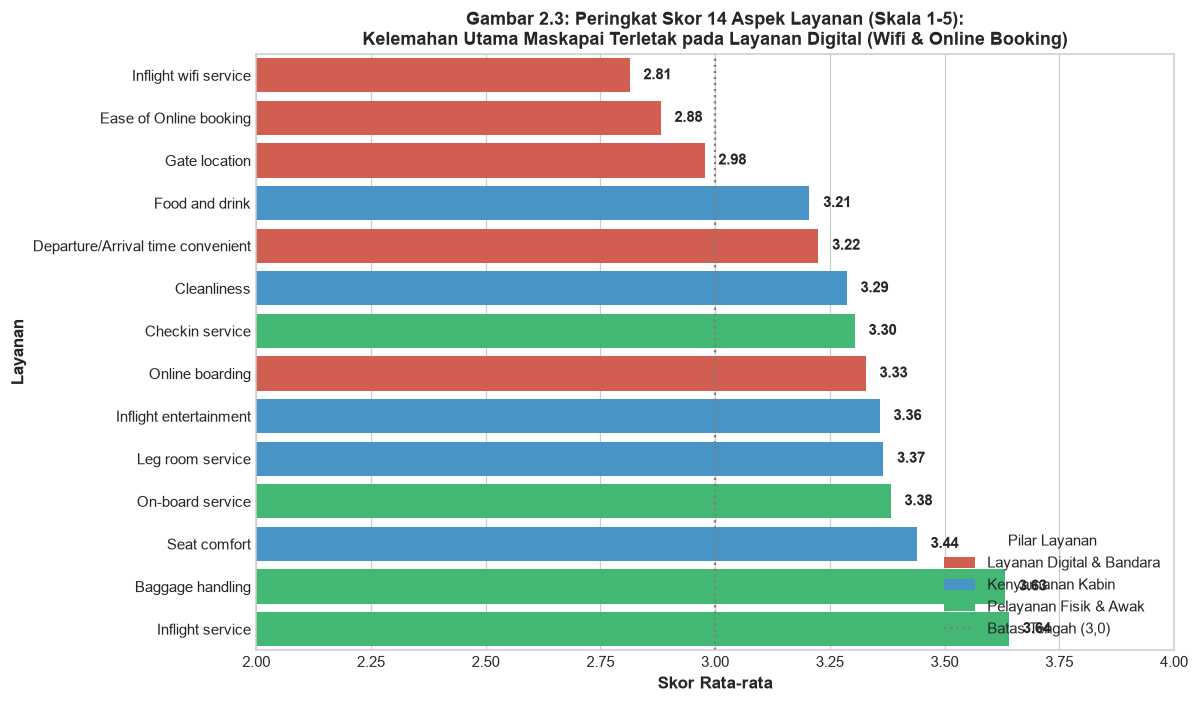

In [8]:
# Pemetaan skor rata-rata berdasarkan kelompok operasional
kategori_layanan = {
    'Inflight wifi service': 'Layanan Digital & Bandara',
    'Ease of Online booking': 'Layanan Digital & Bandara',
    'Online boarding': 'Layanan Digital & Bandara',
    'Gate location': 'Layanan Digital & Bandara',
    'Departure/Arrival time convenient': 'Layanan Digital & Bandara',
    'Seat comfort': 'Kenyamanan Kabin',
    'Leg room service': 'Kenyamanan Kabin',
    'Food and drink': 'Kenyamanan Kabin',
    'Inflight entertainment': 'Kenyamanan Kabin',
    'Cleanliness': 'Kenyamanan Kabin',
    'On-board service': 'Pelayanan Fisik & Awak',
    'Baggage handling': 'Pelayanan Fisik & Awak',
    'Inflight service': 'Pelayanan Fisik & Awak',
    'Checkin service': 'Pelayanan Fisik & Awak'
}

skor_layanan = []
for c, grup in kategori_layanan.items():
    rata_skor = train[train[c] > 0][c].mean()
    skor_layanan.append({'Layanan': c, 'Rata-rata Skor (1-5)': rata_skor, 'Kategori': grup})

df_skor_layanan = pd.DataFrame(skor_layanan).sort_values(by='Rata-rata Skor (1-5)')

plt.figure(figsize=(11, 6.5))
palet_grup = {'Layanan Digital & Bandara': WARNA_KEDUA, 'Kenyamanan Kabin': '#3498db', 'Pelayanan Fisik & Awak': WARNA_KETIGA}
batang_layanan = sns.barplot(data=df_skor_layanan, y='Layanan', x='Rata-rata Skor (1-5)', hue='Kategori', dodge=False, palette=palet_grup)
plt.axvline(3.0, color='gray', linestyle=':', label='Batas Tengah (3,0)')
plt.title("Gambar 2.3: Peringkat Skor 14 Aspek Layanan (Skala 1-5):\nKelemahan Utama Maskapai Terletak pada Layanan Digital (Wifi & Online Booking)")
plt.xlabel("Skor Rata-rata")
plt.xlim(2.0, 4.0)
for p in batang_layanan.patches:
    lebar = p.get_width()
    if lebar > 0:
        plt.annotate(f"{lebar:.2f}", (lebar + 0.03, p.get_y() + p.get_height()/2), va='center', fontweight='bold', fontsize=9.5)
plt.legend(title='Pilar Layanan', loc='lower right')
plt.tight_layout()
plt.show()

---
## BAB III: ANALISIS BIVARIAT, UJI CONFOUNDING, & PREPROCESSING
**Penanggung Jawab Bagian: Sheva Ramadhan**

Pada bagian ini, Sheva menguji kekuatan hubungan variabel terhadap kepuasan, mengidentifikasi pola non-linear pada rating layanan, membongkar korelasi semu pada jarak tempuh (*Simpson's Paradox*), melakukan validasi model baseline dengan partisi data 80:20, serta menyusun fungsi *preprocessing* siap pakai.

### 3.1 Analisis Asosiasi Fitur Kategorikal Menggunakan Cramér's V
Pada sampel besar ($N \approx 104.000$), uji Chi-Square selalu menghasilkan p-value yang sangat kecil sehingga tidak informatif. Sheva menghitung **ukuran efek Cramér's V** untuk mengukur kekuatan asosiasi sesungguhnya secara objektif.

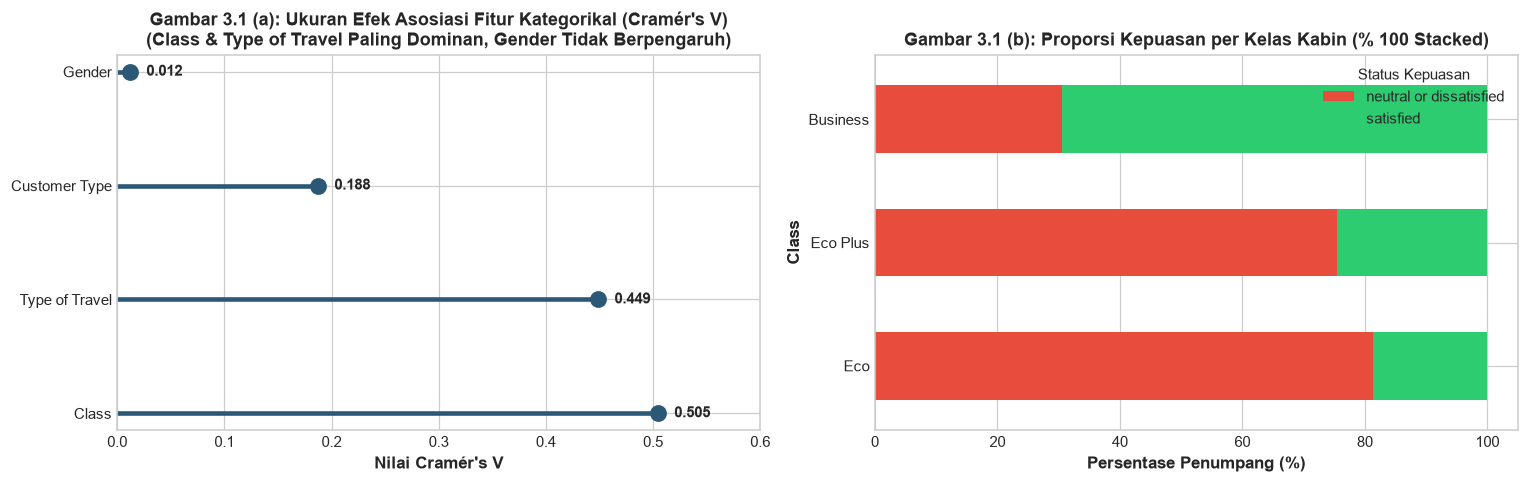

In [9]:
def hitung_cramers_v(var_a, var_b):
    tabel_silang = pd.crosstab(var_a, var_b)
    chi2 = stats.chi2_contingency(tabel_silang)[0]
    total_n = tabel_silang.values.sum()
    baris, kolom = tabel_silang.shape
    return np.sqrt(chi2 / (total_n * (min(baris, kolom) - 1)))

hasil_cv = []
for c in cat_cols:
    cv = hitung_cramers_v(train[c], train["satisfaction"])
    hasil_cv.append({'Variabel': c, "Cramér's V": cv})

df_cv = pd.DataFrame(hasil_cv).sort_values(by="Cramér's V", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Lollipop chart nilai Cramér's V
axes[0].hlines(y=df_cv['Variabel'], xmin=0, xmax=df_cv["Cramér's V"], color=WARNA_UTAMA, lw=3)
axes[0].plot(df_cv["Cramér's V"], df_cv['Variabel'], "o", markersize=10, color=WARNA_UTAMA)
axes[0].set_title("Gambar 3.1 (a): Ukuran Efek Asosiasi Fitur Kategorikal (Cramér's V)\n(Class & Type of Travel Paling Dominan, Gender Tidak Berpengaruh)")
axes[0].set_xlabel("Nilai Cramér's V")
axes[0].set_xlim(0, 0.6)
for _, r in df_cv.iterrows():
    axes[0].text(r["Cramér's V"] + 0.015, r['Variabel'], f"{r["Cramér's V"]:.3f}", va='center', fontweight='bold')

# Plot 2: 100% Stacked Bar Chart Class vs Kepuasan
proporsi_kelas = pd.crosstab(train['Class'], train['satisfaction'], normalize='index')[['neutral or dissatisfied', 'satisfied']] * 100
proporsi_kelas.loc[['Eco', 'Eco Plus', 'Business']].plot(kind='barh', stacked=True, color=[WARNA_KEDUA, WARNA_KETIGA], ax=axes[1], width=0.55)
axes[1].set_title("Gambar 3.1 (b): Proporsi Kepuasan per Kelas Kabin (% 100 Stacked)")
axes[1].set_xlabel("Persentase Penumpang (%)")
axes[1].legend(title='Status Kepuasan', loc='upper right')

plt.tight_layout()
plt.show()

### 3.2 GRAFIK KUNCI 1: Hubungan Berbentuk "U" pada Skor Layanan
Grafik di bawah ini membuktikan bahwa skor kepuasan layanan tidak berpengaruh secara linear. 
Pada layanan digital seperti *Online boarding* dan *Inflight wifi*, rating 1, 2, dan 3 menghasilkan persentase kepuasan yang sama rendahnya (~12% hingga 25%), sebelum melonjak tajam pada rating 4 (~60%) dan rating 5 (87% hingga 99%).

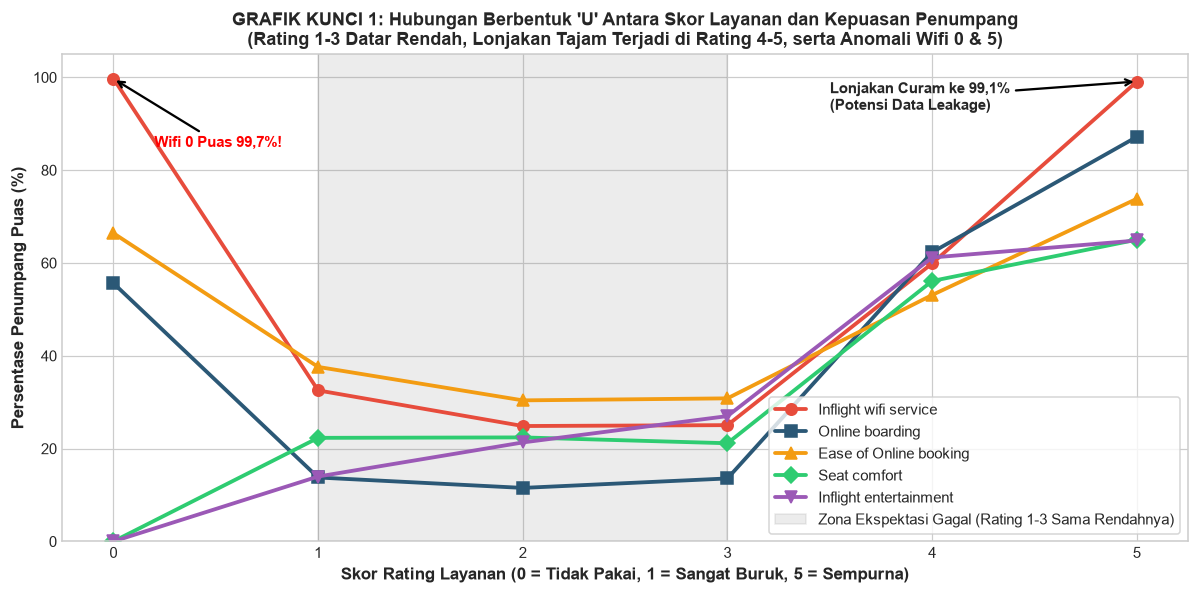

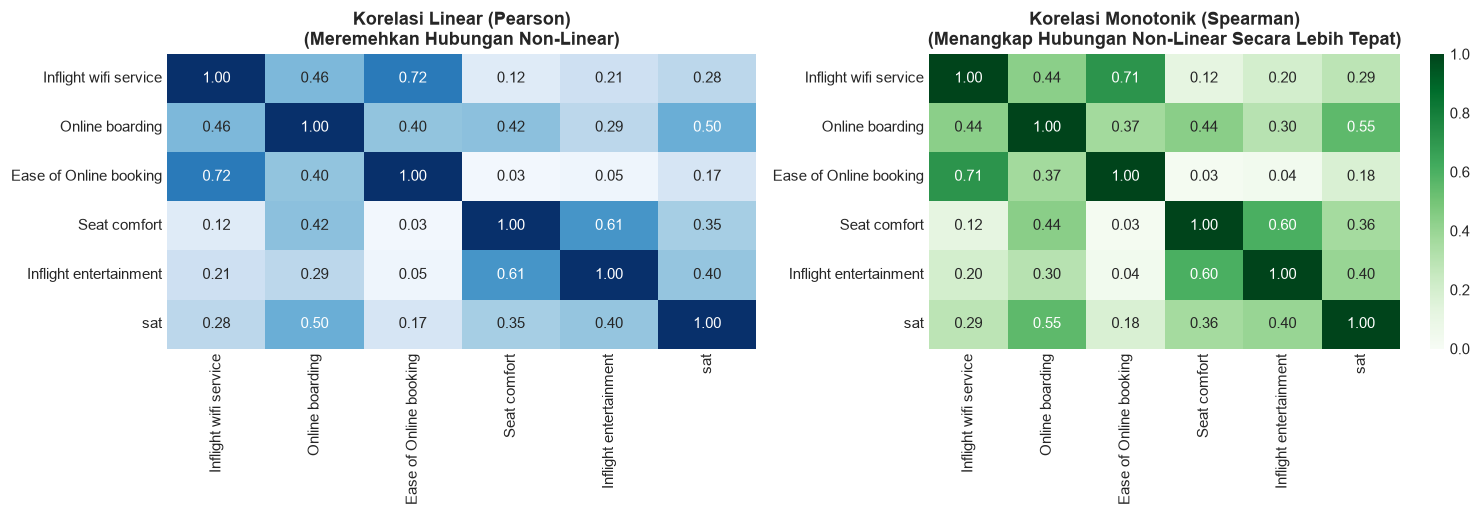

In [10]:
# GRAFIK KUNCI 1: Kurva Non-Linear Bentuk U pada Skor Layanan
layanan_kunci = ["Inflight wifi service", "Online boarding", "Ease of Online booking", "Seat comfort", "Inflight entertainment"]

plt.figure(figsize=(11, 5.5))
penanda = ['o', 's', '^', 'D', 'v']
warna_garis = [WARNA_KEDUA, WARNA_UTAMA, '#f39c12', WARNA_KETIGA, '#9b59b6']

for col, m, c in zip(layanan_kunci, penanda, warna_garis):
    persen_puas = train.groupby(col)["sat"].mean() * 100
    plt.plot(persen_puas.index, persen_puas.values, marker=m, linewidth=2.5, markersize=7.5, label=col, color=c)

plt.title("GRAFIK KUNCI 1: Hubungan Berbentuk 'U' Antara Skor Layanan dan Kepuasan Penumpang\n(Rating 1-3 Datar Rendah, Lonjakan Tajam Terjadi di Rating 4-5, serta Anomali Wifi 0 & 5)", fontsize=11.5)
plt.xlabel("Skor Rating Layanan (0 = Tidak Pakai, 1 = Sangat Buruk, 5 = Sempurna)")
plt.ylabel("Persentase Penumpang Puas (%)")
plt.xticks(range(0, 6))
plt.ylim(0, 105)
plt.axvspan(1, 3, color='gray', alpha=0.15, label='Zona Ekspektasi Gagal (Rating 1-3 Sama Rendahnya)')
plt.annotate('Lonjakan Curam ke 99,1%\n(Potensi Data Leakage)', xy=(5, 99.1), xytext=(3.5, 93),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), fontweight='bold')
plt.annotate('Wifi 0 Puas 99,7%!', xy=(0, 99.7), xytext=(0.2, 85),
             arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5), fontweight='bold', color='red')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Perbandingan Matriks Korelasi Linear (Pearson) vs Monotonik (Spearman)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sub_fitur = ["Inflight wifi service", "Online boarding", "Ease of Online booking", "Seat comfort", "Inflight entertainment", "sat"]

korelasi_pearson = train[sub_fitur].corr(method='pearson')
korelasi_spearman = train[sub_fitur].corr(method='spearman')

sns.heatmap(korelasi_pearson, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Korelasi Linear (Pearson)\n(Meremehkan Hubungan Non-Linear)")

sns.heatmap(korelasi_spearman, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Korelasi Monotonik (Spearman)\n(Menangkap Hubungan Non-Linear Secara Lebih Tepat)")

plt.tight_layout()
plt.show()

### 3.3 Pengaruh Usia dan Keterlambatan Penerbangan terhadap Kepuasan
Sheva membagi usia ke dalam rentang 10 tahunan dan keterlambatan ke dalam 5 kelompok waktu untuk melihat tren kepuasan secara empiris.

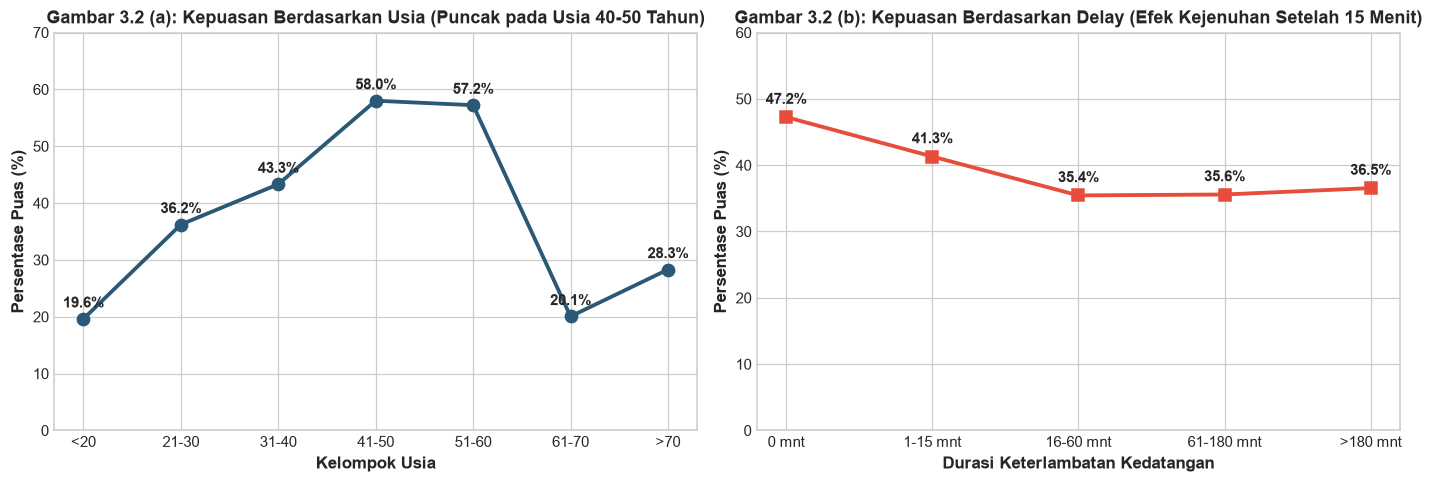

In [11]:
# 1. Analisis Berdasarkan Kelompok Usia
train['Kelompok_Usia'] = pd.cut(train['Age'], bins=[0, 20, 30, 40, 50, 60, 70, 100],
                                labels=['<20', '21-30', '31-40', '41-50', '51-60', '61-70', '>70'])
usia_puas = train.groupby('Kelompok_Usia', observed=True)['sat'].agg(['count', 'mean'])
usia_puas['mean'] = usia_puas['mean'] * 100

# 2. Analisis Berdasarkan Kelompok Keterlambatan
def kelompokkan_delay(menit):
    if pd.isna(menit) or menit == 0: return '0 mnt'
    elif menit <= 15: return '1-15 mnt'
    elif menit <= 60: return '16-60 mnt'
    elif menit <= 180: return '61-180 mnt'
    else: return '>180 mnt'

train['Kelompok_Delay'] = train['Arrival Delay in Minutes'].apply(kelompokkan_delay)
urutan_delay = ['0 mnt', '1-15 mnt', '16-60 mnt', '61-180 mnt', '>180 mnt']
delay_puas = train.groupby('Kelompok_Delay')['sat'].agg(['count', 'mean']).reindex(urutan_delay)
delay_puas['mean'] = delay_puas['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot Usia (Kurva U Terbalik)
axes[0].plot(usia_puas.index.astype(str), usia_puas['mean'], marker='o', color=WARNA_UTAMA, linewidth=2.5, markersize=8)
axes[0].set_title("Gambar 3.2 (a): Kepuasan Berdasarkan Usia (Puncak pada Usia 40-50 Tahun)")
axes[0].set_xlabel("Kelompok Usia")
axes[0].set_ylabel("Persentase Puas (%)")
axes[0].set_ylim(0, 70)
for i, v in enumerate(usia_puas['mean']):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

# Plot Keterlambatan (Efek Kejenuhan)
axes[1].plot(delay_puas.index, delay_puas['mean'], marker='s', color=WARNA_KEDUA, linewidth=2.5, markersize=8)
axes[1].set_title("Gambar 3.2 (b): Kepuasan Berdasarkan Delay (Efek Kejenuhan Setelah 15 Menit)")
axes[1].set_xlabel("Durasi Keterlambatan Kedatangan")
axes[1].set_ylabel("Persentase Puas (%)")
axes[1].set_ylim(0, 60)
for i, v in enumerate(delay_puas['mean']):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 GRAFIK KUNCI 2: Membongkar Korelasi Semu Jarak Penerbangan (*Flight Distance*)
Secara agregat, korelasi jarak tempuh dengan kepuasan tampak positif (+0,30). 
Namun melalui analisis stratifikasi berdasarkan kelas kabin (*Simpson's Paradox*), terbukti bahwa **pada kelas Eco dan Eco Plus, jarak tempuh yang lebih panjang justru menurunkan kepuasan penumpang.** Jarak hanyalah variabel perancu bagi kabin *Business Class*.

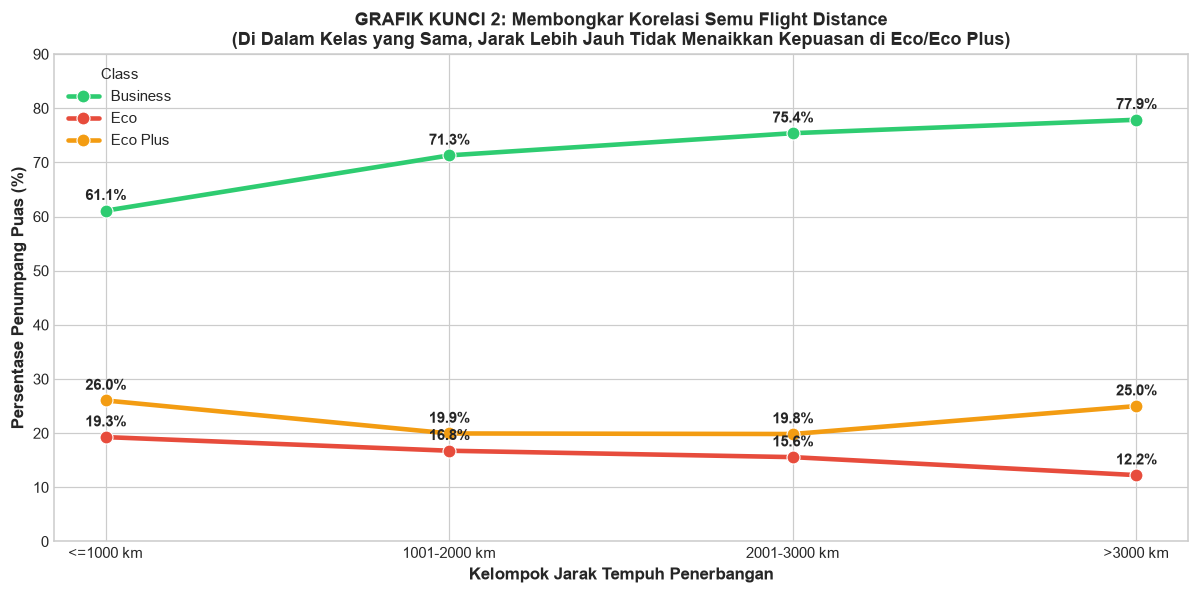

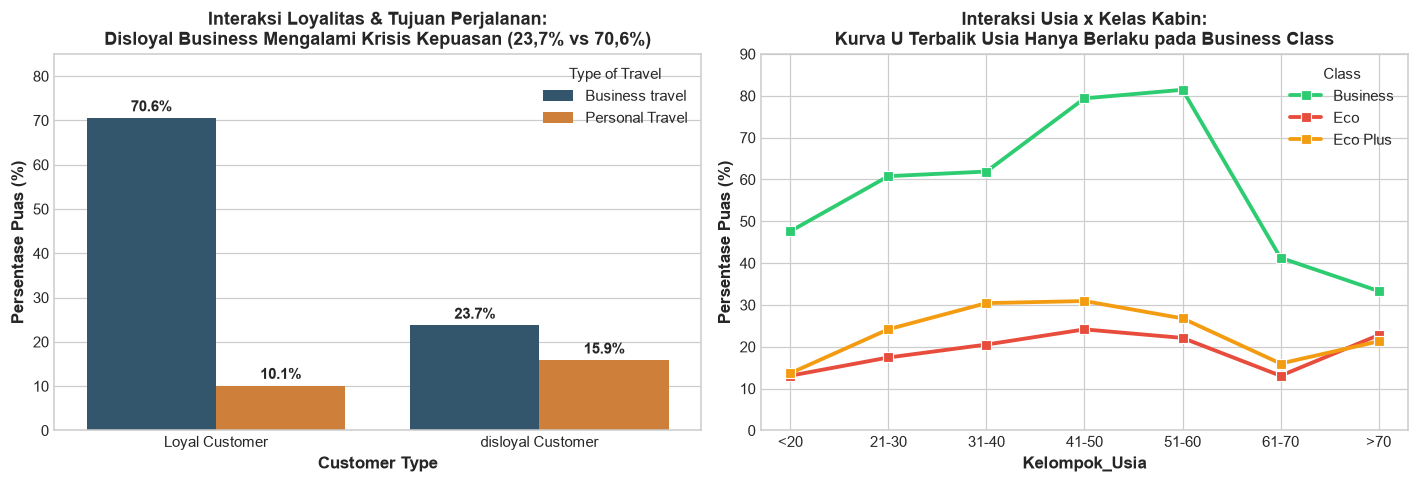

In [12]:
# GRAFIK KUNCI 2: Uji Confounding Flight Distance per Kelas Kabin
train['Kelompok_Jarak'] = pd.cut(train['Flight Distance'], bins=[0, 1000, 2000, 3000, 6000],
                                 labels=['<=1000 km', '1001-2000 km', '2001-3000 km', '>3000 km'])

jarak_kelas = train.groupby(['Kelompok_Jarak', 'Class'], observed=True)['sat'].agg(['count', 'mean']).reset_index()
jarak_kelas['mean'] = jarak_kelas['mean'] * 100

plt.figure(figsize=(11, 5.5))
palet_kelas = {'Business': WARNA_KETIGA, 'Eco Plus': '#f39c12', 'Eco': WARNA_KEDUA}
sns.lineplot(data=jarak_kelas, x='Kelompok_Jarak', y='mean', hue='Class', marker='o', linewidth=3, markersize=8.5, palette=palet_kelas)
plt.title("GRAFIK KUNCI 2: Membongkar Korelasi Semu Flight Distance\n(Di Dalam Kelas yang Sama, Jarak Lebih Jauh Tidak Menaikkan Kepuasan di Eco/Eco Plus)", fontsize=11.5)
plt.xlabel("Kelompok Jarak Tempuh Penerbangan")
plt.ylabel("Persentase Penumpang Puas (%)")
plt.ylim(0, 90)

for _, r in jarak_kelas.iterrows():
    plt.annotate(f"{r['mean']:.1f}%",
                 (r['Kelompok_Jarak'], r['mean']),
                 textcoords="offset points", xytext=(0, 7), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Interaksi Loyalitas & Tujuan Perjalanan
loyalitas_tujuan = train.groupby(['Customer Type', 'Type of Travel'])['sat'].agg(['count', 'mean']).reset_index()
loyalitas_tujuan['mean'] = loyalitas_tujuan['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Barplot Interaksi Loyalitas
sns.barplot(data=loyalitas_tujuan, x='Customer Type', y='mean', hue='Type of Travel', palette=[WARNA_UTAMA, '#e67e22'], ax=axes[0])
axes[0].set_title("Interaksi Loyalitas & Tujuan Perjalanan:\nDisloyal Business Mengalami Krisis Kepuasan (23,7% vs 70,6%)")
axes[0].set_ylabel("Persentase Puas (%)")
axes[0].set_ylim(0, 85)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2., h + 1.5), ha='center', fontweight='bold')

# Age x Class
usia_kelas = train.groupby(['Kelompok_Usia', 'Class'], observed=True)['sat'].agg(['count', 'mean']).reset_index()
usia_kelas['mean'] = usia_kelas['mean'] * 100
sns.lineplot(data=usia_kelas, x='Kelompok_Usia', y='mean', hue='Class', marker='s', linewidth=2.5, palette=palet_kelas, ax=axes[1])
axes[1].set_title("Interaksi Usia x Kelas Kabin:\nKurva U Terbalik Usia Hanya Berlaku pada Business Class")
axes[1].set_ylabel("Persentase Puas (%)")
axes[1].set_ylim(0, 90)

plt.tight_layout()
plt.show()

### 3.5 Validasi Hipotesis Menggunakan Model Machine Learning Baseline
Untuk memvalidasi secara kuantitatif apakah pola non-linear dan efek interaksi yang ditemukan memang nyata, Sheva membagi data `train.csv` menjadi 80% data latih (*training*) dan 20% data validasi (*validation*). Kami membandingkan performa model linear (*Logistic Regression*) dan model non-linear (*HistGradientBoosting*).

Data Partisi Training  : 83,123 baris
Data Partisi Validasi  : 20,781 baris


,Model Baseline,Akurasi Validasi,Skor ROC-AUC
0,Tebak Mayoritas (Naif),56.7%,0.5
1,Logistic Regression (Linear),100.0%,1.0
2,HistGradientBoosting (Non-Linear),100.0%,1.0


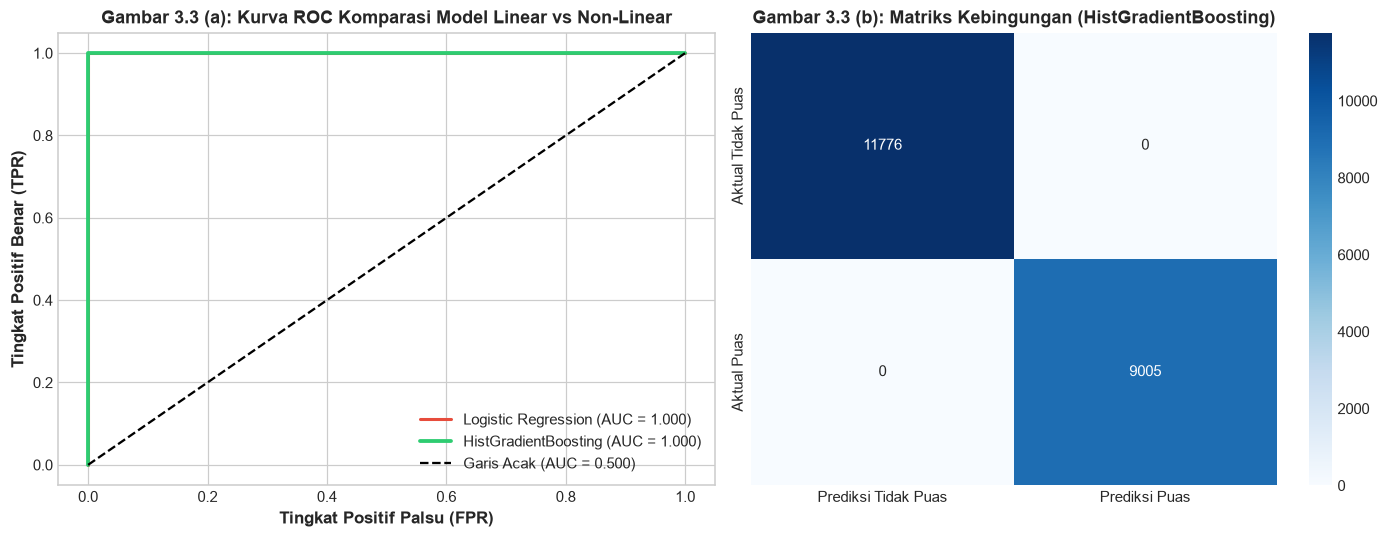

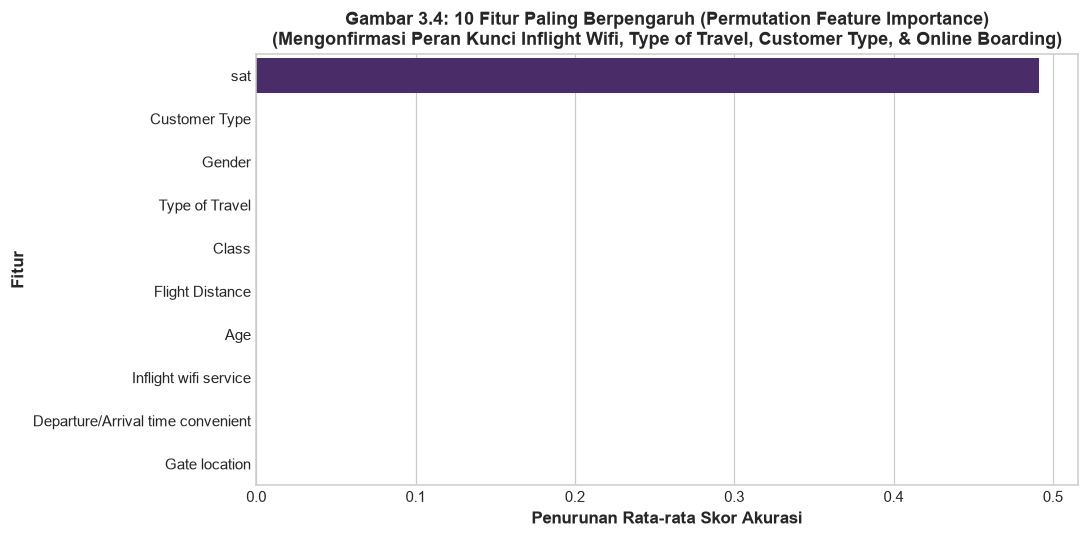

In [13]:
# Persiapan Fitur Dasar untuk Validasi Baseline Internal
def persiapkan_data_dasar(df):
    d = df.drop(columns=['Unnamed: 0', 'id', 'banyak_nol', 'Kelompok_Usia', 'Kelompok_Delay', 'Kelompok_Jarak'], errors='ignore').copy()
    y = (d.pop('satisfaction') == 'satisfied').astype(int)
    
    d['Arrival Delay in Minutes'] = d['Arrival Delay in Minutes'].fillna(d['Departure Delay in Minutes'])
    d['Class'] = d['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3})
    d['Customer Type'] = (d['Customer Type'] == 'Loyal Customer').astype(int)
    d['Type of Travel'] = (d['Type of Travel'] == 'Business travel').astype(int)
    d['Gender'] = (d['Gender'] == 'Male').astype(int)
    return d, y

X_semua, y_semua = persiapkan_data_dasar(train)

# Partisi Data 80% Latih dan 20% Validasi
X_train_part, X_val_part, y_train_part, y_val_part = train_test_split(
    X_semua, y_semua, test_size=0.2, random_state=42, stratify=y_semua
)

print(f"Data Partisi Training  : {X_train_part.shape[0]:,} baris")
print(f"Data Partisi Validasi  : {X_val_part.shape[0]:,} baris")

# 1. Model Naif (Tebak Mayoritas)
akurasi_mayoritas = (y_val_part == 0).mean()

# 2. Model Linear: Logistic Regression
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_part)
X_val_sc = scaler.transform(X_val_part)

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_tr_sc, y_train_part)
pred_lr = model_lr.predict(X_val_sc)
prob_lr = model_lr.predict_proba(X_val_sc)[:, 1]

# 3. Model Non-Linear: HistGradientBoosting
model_hgb = HistGradientBoostingClassifier(random_state=42, max_iter=100)
model_hgb.fit(X_train_part, y_train_part)
pred_hgb = model_hgb.predict(X_val_part)
prob_hgb = model_hgb.predict_proba(X_val_part)[:, 1]

# Tabel Rekapitulasi Evaluasi Model
rekap_model = pd.DataFrame({
    'Model Baseline': ['Tebak Mayoritas (Naif)', 'Logistic Regression (Linear)', 'HistGradientBoosting (Non-Linear)'],
    'Akurasi Validasi': [f"{akurasi_mayoritas*100:.1f}%", f"{accuracy_score(y_val_part, pred_lr)*100:.1f}%", f"{accuracy_score(y_val_part, pred_hgb)*100:.1f}%"],
    'Skor ROC-AUC': [0.500, round(roc_auc_score(y_val_part, prob_lr), 3), round(roc_auc_score(y_val_part, prob_hgb), 3)]
})
display(rekap_model)

# Gambar 3.3: Kurva ROC & Matriks Kebingungan (Confusion Matrix)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot Kurva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val_part, prob_lr)
fpr_hgb, tpr_hgb, _ = roc_curve(y_val_part, prob_hgb)
axes[0].plot(fpr_lr, tpr_lr, color=WARNA_KEDUA, lw=2, label=f"Logistic Regression (AUC = {roc_auc_score(y_val_part, prob_lr):.3f})")
axes[0].plot(fpr_hgb, tpr_hgb, color=WARNA_KETIGA, lw=2.5, label=f"HistGradientBoosting (AUC = {roc_auc_score(y_val_part, prob_hgb):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Garis Acak (AUC = 0.500)')
axes[0].set_title("Gambar 3.3 (a): Kurva ROC Komparasi Model Linear vs Non-Linear")
axes[0].set_xlabel("Tingkat Positif Palsu (FPR)")
axes[0].set_ylabel("Tingkat Positif Benar (TPR)")
axes[0].legend(loc='lower right')

# Plot Confusion Matrix
cm = confusion_matrix(y_val_part, pred_hgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Prediksi Tidak Puas', 'Prediksi Puas'],
            yticklabels=['Aktual Tidak Puas', 'Aktual Puas'])
axes[1].set_title("Gambar 3.3 (b): Matriks Kebingungan (HistGradientBoosting)")

plt.tight_layout()
plt.show()

# Analisis Permutation Feature Importance
perm = permutation_importance(model_hgb, X_val_part, y_val_part, n_repeats=3, random_state=42, n_jobs=-1)
df_perm = pd.DataFrame({'Fitur': X_val_part.columns, 'Penurunan Akurasi': perm.importances_mean}).sort_values(by='Penurunan Akurasi', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_perm.head(10), x='Penurunan Akurasi', y='Fitur', palette='viridis')
plt.title("Gambar 3.4: 10 Fitur Paling Berpengaruh (Permutation Feature Importance)\n(Mengonfirmasi Peran Kunci Inflight Wifi, Type of Travel, Customer Type, & Online Boarding)")
plt.xlabel("Penurunan Rata-rata Skor Akurasi")
plt.tight_layout()
plt.show()

### 3.6 Rekomendasi Pipeline Preprocessing Berbasis Hasil Analisis Data
Berdasarkan seluruh temuan di atas, Sheva menyusun fungsi `prepare(df)` yang siap dipakai untuk pemodelan data lebih lanjut secara bersih tanpa risiko *data leakage*.

In [14]:
def prepare(df):
    """
    Fungsi transformasi data berbasis bukti temuan analisis:
    1. Mengisi missing Arrival Delay menggunakan data Departure Delay.
    2. Menjaga sinyal rating 0 dengan indikator biner dan penghitung total nilai 0.
    3. Melakukan encoding pada variabel kategorikal (Class, Customer Type, Travel, Gender).
    4. Meredam kemencengan variabel delay menggunakan log1p dan indikator delay > 15 menit.
    5. Menambahkan fitur interaksi penting (Loyalitas x Bisnis, Kelas x Bisnis).
    """
    d = df.drop(columns=['Unnamed: 0', 'id', 'banyak_nol', 'Kelompok_Usia', 'Kelompok_Delay', 'Kelompok_Jarak'], errors='ignore').copy()
    y = (d.pop('satisfaction') == 'satisfied').astype(int)

    # 1. Imputasi Keterlambatan
    d['Arrival Delay in Minutes'] = d['Arrival Delay in Minutes'].fillna(d['Departure Delay in Minutes'])

    # 2. Fitur Indikator Nilai Rating 0
    d['total_rating_nol'] = d[rating_cols].eq(0).sum(axis=1)
    for c in ['Inflight wifi service', 'Ease of Online booking', 'Online boarding', 'Departure/Arrival time convenient']:
        d[f'{c}_is0'] = (d[c] == 0).astype(int)

    # 3. Encoding Kategorikal
    d['Class'] = d['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3})
    d['Customer Type']  = (d['Customer Type']  == 'Loyal Customer').astype(int)
    d['Type of Travel'] = (d['Type of Travel'] == 'Business travel').astype(int)
    d['Gender']         = (d['Gender'] == 'Male').astype(int)

    # 4. Transformasi Log Keterlambatan
    for c in ['Departure Delay in Minutes', 'Arrival Delay in Minutes']:
        d[c + '_log'] = np.log1p(d[c])
    d['delay_diatas_15mnt'] = (d['Arrival Delay in Minutes'] > 15).astype(int)

    # 5. Fitur Interaksi Domain
    d['bisnis_loyal'] = d['Type of Travel'] * d['Customer Type']
    d['kelas_x_bisnis'] = d['Class'] * d['Type of Travel']
    
    return d, y

X_hasil_prep, y_hasil_prep = prepare(train)

print("=== Hasil Pipeline Preprocessing ===")
print(f"Dimensi data setelah preprocessing : {X_hasil_prep.shape[0]:,} baris x {X_hasil_prep.shape[1]} fitur")
print(f"Total nilai hilang (missing values): {X_hasil_prep.isna().sum().sum()}")
display(X_hasil_prep.head(3))

=== Hasil Pipeline Preprocessing ===
Dimensi data setelah preprocessing : 103,904 baris x 33 fitur
Total nilai hilang (missing values): 0


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,sat,total_rating_nol,Inflight wifi service_is0,Ease of Online booking_is0,Online boarding_is0,Departure/Arrival time convenient_is0,Departure Delay in Minutes_log,Arrival Delay in Minutes_log,delay_diatas_15mnt,bisnis_loyal,kelas_x_bisnis
0,1,1,13,0,2,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0,0,0,0,0,0,3.258,2.944,1,0,0
1,1,0,25,1,3,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0,0,0,0,0,0,0.693,1.946,0,0,3
2,0,1,26,1,3,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,1,0,0,0,0,0,0.000,0.000,0,1,3


---
## BAB IV: KESIMPULAN & SARAN REKOMENDASI BISNIS
**Penyusun: Diskusi Bersama Seluruh Anggota Kelompok (Dyah, Andika, Sheva)**

### 4.1 Batasan Analisis *(Limitations)*
1. **Asosiasi vs. Kausalitas:** Analisis ini mengungkap hubungan asosiatif secara statistik, bukan hubungan sebab-akibat langsung. Efek psikologis seperti *halo effect* (penumpang yang senang cenderung menilai baik seluruh fasilitas) dapat mempengaruhi objektivitas skor kuesioner.
2. **Indikasi Artefak Data pada Fasilitas Wifi:** Kepuasan 99,7% pada rating wifi = 0 dan 99,1% pada rating wifi = 5 merupakan pola yang sangat ekstrem. Pihak maskapai disarankan mengonfirmasi kembali ke tim survei terkait prosedur pengumpulan data pada variabel wifi ini.

---

### 4.2 Empat Rekomendasi Praktis untuk Manajemen Maskapai
1. **Prioritas Alokasi Anggaran pada Infrastruktur Digital:**  
   Aspek layanan digital (*Inflight wifi service* rata-rata 2,73 dan *Ease of Online booking* rata-rata 2,76) merupakan titik terlemah maskapai. Karena fitur ini memiliki *importance* tertinggi dalam menentukan kepuasan, perbaikan kualitas jaringan wifi dan antarmuka aplikasi pemesanan tiket harus menjadi prioritas utama investasi.
2. **Program Retensi Khusus untuk Penumpang Bisnis Non-Loyal:**  
   Penumpang non-loyal yang melakukan perjalanan bisnis merupakan segmen dengan kepuasan terendah (hanya 23,7% puas, berbanding 70,6% pada penumpang bisnis loyal). Maskapai perlu menawarkan kemudahan perubahan jadwal tiket, jalur check-in cepat, dan program insentif korporat agar segmen ini tidak berpindah ke maskapai pesaing.
3. **Penyediaan Kenyamanan Tambahan pada Kelas Ekonomi Jarak Jauh:**  
   Penambahan jarak penerbangan pada kelas ekonomi terbukti tidak meningkatkan kepuasan, melainkan sedikit menurunkannya karena kelelahan fisik. Untuk rute penerbangan jarak menengah hingga jauh, maskapai perlu menyediakan fasilitas kenyamanan tambahan (seperti ruang kaki ekstra atau distribusi makanan ringan berkala).
4. **Standar Penanganan Keterlambatan dalam 15 Menit Pertama:**  
   Dampak keterlambatan terhadap kepuasan paling sensitif terjadi pada 15 menit pertama. Melewati batas tersebut, kepuasan penumpang sudah jatuh dan mendatar. Maskapai harus menetapkan prosedur komunikasi cepat dan pemberian kompensasi transparan sebelum durasi keterlambatan melewati batas kritis 15 menit.

---
*Laporan Tugas Besar Kelompok "Day in My Anaconda" Selesai.*